In [1]:
from tqdm import tqdm

import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE

from pathlib import Path
import random
from PIL import Image

In [2]:
path = Path("50k")

all_images = list(path.rglob("*.jpg"))
num_images = len(all_images)

print(f"Number of jpg files: {num_images}")

test_dataset_count = num_images

Number of jpg files: 50000


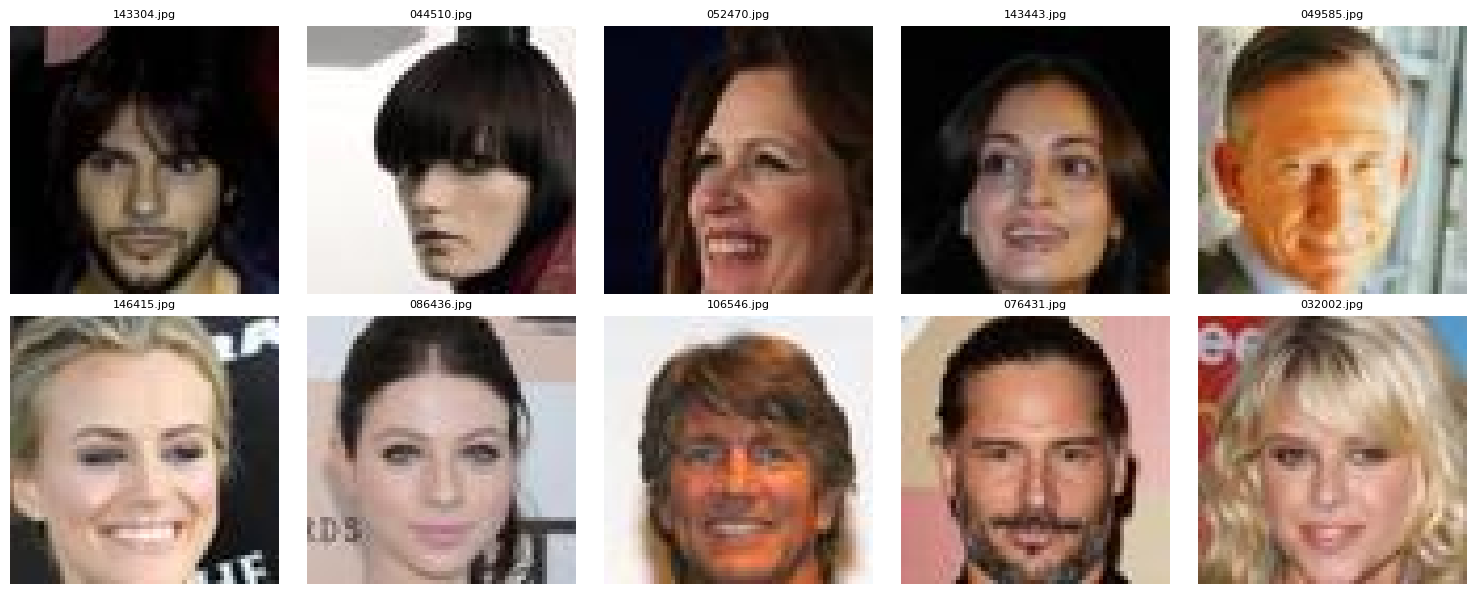

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax in axes.flatten():
    img_path = random.choice(all_images)

    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [4]:
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

print("Using device:", device)

Using device: cpu


In [5]:
SEED = 42

train_paths, temp_paths = train_test_split(
    all_images, test_size=0.2, random_state=SEED
)

val_paths, test_paths = train_test_split(
    temp_paths, test_size=0.5, random_state=SEED
)

if train_paths is not None:
    print("Train:", len(train_paths))
    print("Val:", len(val_paths))
    print("Test:", len(test_paths))

if train_paths:
    test_train_count = len(train_paths)
    test_val_count = len(val_paths)
    test_test_count = len(test_paths)
    test_split_seed = SEED

Train: 40000
Val: 5000
Test: 5000


In [6]:
IMAGE_SIZE = 64

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

if IMAGE_SIZE:
    test_image_size = IMAGE_SIZE
    test_train_transform_names = [type(t).__name__ for t in train_transform.transforms]
    test_test_transform_names = [type(t).__name__ for t in test_transform.transforms]
    test_train_flip_p = train_transform.transforms[1].p

In [8]:
class CelebADataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image

In [9]:
train_dataset = CelebADataset(train_paths, transform=train_transform)

val_dataset = CelebADataset(val_paths, transform=test_transform)

test_dataset = CelebADataset(test_paths, transform=test_transform)

test_dataset_class_train_len = len(train_dataset)
test_dataset_class_val_len = len(val_dataset)
test_dataset_class_test_len = len(test_dataset)

In [10]:
BATCH_SIZE = 64

NUM_WORKERS = 0

# Initialize the DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader) if train_loader is not None else 0}")
print(f"Val batches: {len(val_loader) if val_loader is not None else 0}")
print(f"Test batches: {len(test_loader) if test_loader is not None else 0}")

if BATCH_SIZE:
    test_train_loader_shuffle = train_loader.dataset is not None and train_loader.batch_size == BATCH_SIZE
    test_train_batches_count = len(train_loader)
    test_val_batches_count = len(val_loader)
    test_test_batches_count = len(test_loader)

Batch size: 64
Train batches: 625
Val batches: 79
Test batches: 79


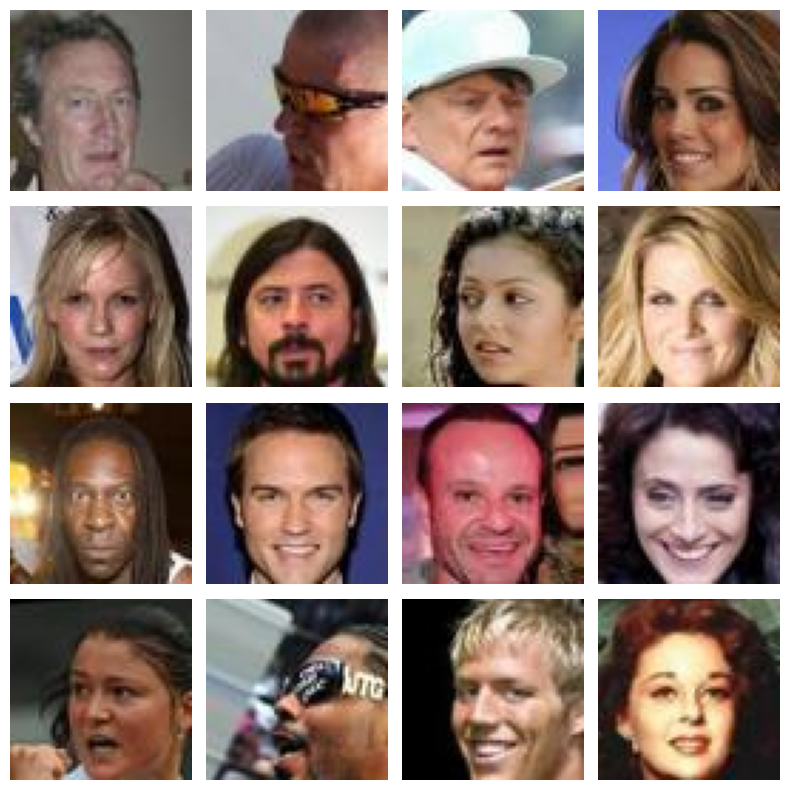

In [11]:
# 1. Get a single batch from the train_loader
images = next(iter(train_loader))

# 2. Plot a grid of 4x4 images
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flatten()):
    # Get the i-th image from the batch
    img = images[i]

    # 3. Permute the dimensions of the image from (C, H, W) to (H, W, C)
    img_permuted = img.permute(1, 2, 0)

    # 4. Display the image
    ax.imshow(img_permuted)
    ax.axis("off")

plt.tight_layout()
plt.show()

test_batch_images_shape = list(images.shape) if images is not None else None

In [13]:
# 1. Get one batch from train_loader
batch = next(iter(train_loader))

# 2. Calculate statistics
batch_shape = batch.shape
batch_min = batch.min().item()
batch_max = batch.max().item()
batch_mean = batch.mean().item()
batch_std = batch.std().item()

print(f"Shape: {batch_shape}")
print(f"Min: {batch_min:.4f}")
print(f"Max: {batch_max:.4f}")
print(f"Mean: {batch_mean:.4f}")
print(f"Std: {batch_std:.4f}")

test_stats_shape = list(batch_shape) if batch_shape is not None else []
test_stats_min = float(batch_min) if batch_min is not None else -1.0
test_stats_max = float(batch_max) if batch_max is not None else -1.0


Shape: torch.Size([64, 3, 64, 64])
Min: 0.0000
Max: 1.0000
Mean: 0.4482
Std: 0.2867


In [14]:
mean = torch.zeros(3)
std = torch.zeros(3)
n_samples = 0

for images in tqdm(train_loader):
    batch_size = images.size(0)

    images_flattened = images.view(batch_size, 3, -1)

    mean += images_flattened.mean(dim=2).sum(dim=0)
    std += images_flattened.std(dim=2).sum(dim=0)

    n_samples += batch_size

mean /= n_samples
std /= n_samples

print(f"Global Mean: {mean}")
print(f"Global Std: {std}")

test_global_mean = mean.tolist() if mean is not None else []
test_global_std = std.tolist() if std is not None else []
test_n_samples = n_samples

100%|██████████| 625/625 [00:08<00:00, 75.31it/s]

Global Mean: tensor([0.5166, 0.4155, 0.3625])
Global Std: tensor([0.2598, 0.2320, 0.2243])


In [23]:
torch.save(
    {
        "train": [str(p) for p in train_paths],
        "val": [str(p) for p in val_paths],
        "test": [str(p) for p in test_paths],
    },
    "celeba_splits.pt"
)

<div dir='rtl'>

## پیاده‌سازی Convolutional Autoencoder

</div>

In [15]:
class ConvAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        # Encoder: input shape (3, 64, 64)
        self.encoder = nn.Sequential(
            # 64 -> 32
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # 32 -> 16
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # 16 -> 8
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # 8 -> 4
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        # Flattened encoder output should map to latent_dim
        # 256 channels * 4 * 4 spatial size = 4096
        self.fc_enc = nn.Linear(256 * 4 * 4, latent_dim)

        # Latent vector should map back to flattened feature map
        self.fc_dec = nn.Linear(latent_dim, 256 * 4 * 4)

        # Decoder: reconstruct image back to (3, 64, 64)
        self.decoder = nn.Sequential(
            # 4 -> 8
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # 8 -> 16
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # 16 -> 32
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # 32 -> 64
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        z = self.fc_enc(x)
        return z

    def decode(self, z):
        x = self.fc_dec(z)
        x = x.view(x.size(0), 256, 4, 4)
        x = self.decoder(x)
        return x

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat

In [16]:
# Instantiate the model
LATENT_DIM = 128
ae = ConvAE(LATENT_DIM).to(device)

# Calculate total parameters
total_params = sum(p.numel() for p in ae.parameters())

print(ae)
print("\n" + "="*30)
print(f"Total Parameters: {total_params:,}")
print("="*30)

test_total_params = total_params
test_ae = ae

ConvAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU(inplace=True)
  )
  (fc_enc): Linear(in_features=4096, out_features=128, bias=True)
  (fc_dec): Linear(in_features=128, out_features=4096, bias=True)
  (decoder): 

In [26]:
images = next(iter(train_loader)).to(device)
ae.eval()

with torch.no_grad():
    outputs = ae(images)

print(f"Input batch shape:  {images.shape}")
print(f"Output batch shape: {outputs.shape}")

Input batch shape:  torch.Size([64, 3, 64, 64])
Output batch shape: torch.Size([64, 3, 64, 64])


In [27]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)
images = next(iter(train_loader)).to(device)

ae.train()
optimizer.zero_grad()

outputs = ae(images)
loss = criterion(outputs, images)

loss.backward()
optimizer.step()


train_step_loss = loss.item()

print("Loss:", train_step_loss)

test_ae_one_step_loss = round(train_step_loss, 6)

Loss: 0.1028757095336914


In [28]:
def train_epoch(model, loader, optimizer, criterion, device):
    # 1. Set model to training mode
    model.train()

    running_loss = 0.0

    # 2. Iterate over the data loader
    for images in tqdm(loader, desc="Training", leave=False):
        # a. Move images to device
        images = images.to(device)

        # b. Zero the gradients
        optimizer.zero_grad()

        # c. Forward pass
        outputs = model(images)

        # d. Calculate loss
        loss = criterion(outputs, images)

        # e. Backward pass
        loss.backward()

        # f. Optimizer step
        optimizer.step()

        # Add to total loss
        running_loss += loss.item()

    # 3. Calculate average loss
    average_loss = running_loss / len(loader)

    return average_loss

In [29]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    # 1. Set model to evaluation mode
    model.eval()

    running_loss = 0.0

    # 2. Iterate over the data loader
    for images in loader:

        # 3. Move images to device
        images = images.to(device)

        # 4. Forward pass
        outputs = model(images)

        # 5. Compute reconstruction loss
        loss = criterion(outputs, images)

        # 6. Accumulate loss
        running_loss += loss.item()

    # 7. Compute average loss
    average_loss = running_loss / len(loader)

    return average_loss

In [ ]:
ae = ConvAE(LATENT_DIM).to(device)
optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)
criterion = nn.MSELoss()

EPOCHS = 5

train_losses = []
val_losses = []

best_val = float("inf")

for epoch in range(EPOCHS):

    train_loss = train_epoch(
        ae, train_loader, optimizer, criterion, device
    )

    val_loss = evaluate(
        ae, val_loader, criterion, device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train: {train_loss:.5f} | "
        f"Val: {val_loss:.5f}"
    )

    if val_loss < best_val:
        best_val = val_loss

        torch.save(
            ae.state_dict(),
            "best_ae.pth"
        )

        print("Saved best model.")

KeyboardInterrupt: 

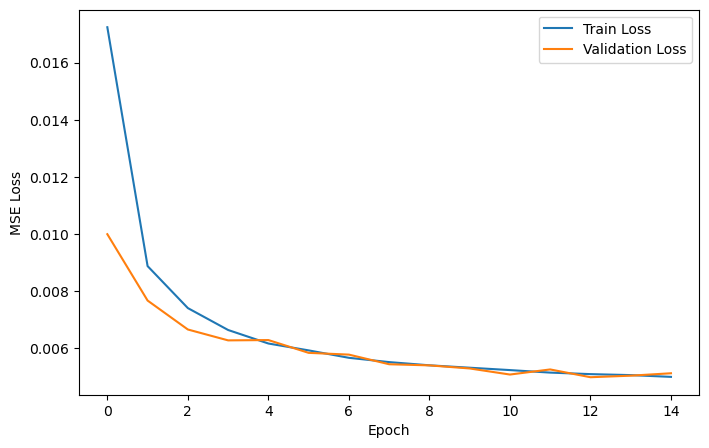

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()

plt.show()

test_plot_train_losses_length = len(train_losses)
test_plot_val_losses_length = len(val_losses)
test_plot_train_loss_first = round(float(train_losses[0]), 6)
test_plot_train_loss_last = round(float(train_losses[-1]), 6)
test_plot_val_loss_first = round(float(val_losses[0]), 6)
test_plot_val_loss_last = round(float(val_losses[-1]), 6)

In [33]:
ae.load_state_dict(
    torch.load(
        "best_ae.pth",
        map_location=device
    )
)
ae.eval()
print("Best model loaded.")

Best model loaded.


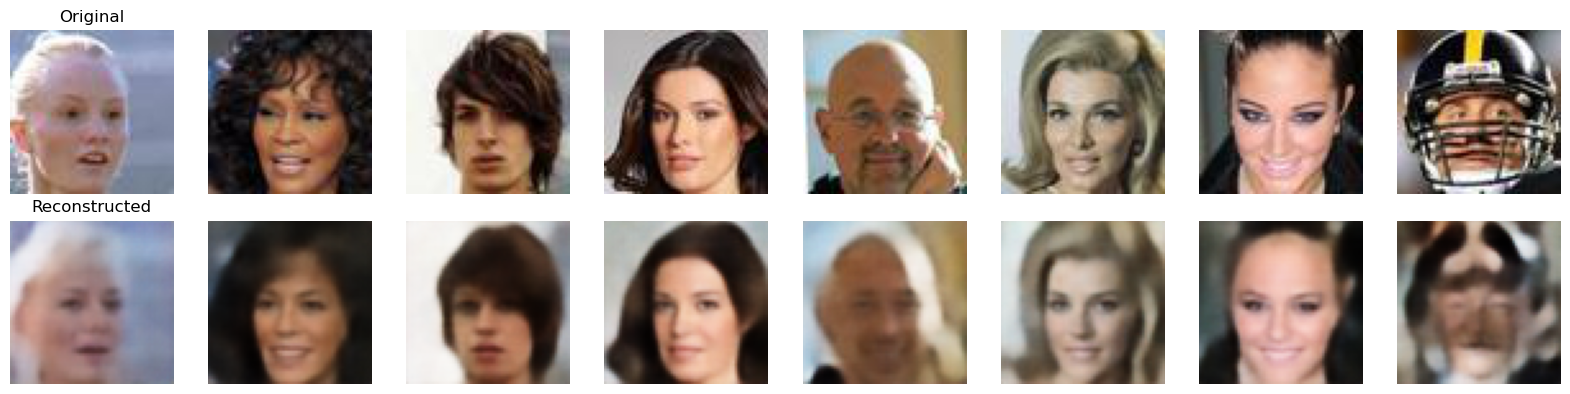

In [34]:
images = next(iter(test_loader))[:8].to(device)

with torch.no_grad():
    recon = ae(images)

images = images.cpu()
recon = recon.cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i in range(8):
    axes[0, i].imshow(images[i].permute(1, 2, 0))
    axes[0, i].axis("off")

    axes[1, i].imshow(recon[i].permute(1, 2, 0))
    axes[1, i].axis("off")

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")

plt.tight_layout()
plt.show()


recon_vis_num_images = 8
recon_vis_input_shape = list(images.shape)
recon_vis_output_shape = list(recon.shape)

recon_vis_input_min = round(float(images.min().item()), 6)
recon_vis_input_max = round(float(images.max().item()), 6)

recon_vis_output_min = round(float(recon.min().item()), 6)
recon_vis_output_max = round(float(recon.max().item()), 6)

In [35]:
submission = {}

# Dataset
submission["test_dataset_count"] = test_dataset_count

submission["test_train_count"] = test_train_count
submission["test_val_count"] = test_val_count
submission["test_test_count"] = test_test_count
submission["test_split_seed"] = test_split_seed


submission["test_image_size"] = test_image_size
submission["test_train_transform_names"] = test_train_transform_names
submission["test_test_transform_names"] = test_test_transform_names
submission["test_train_flip_p"] = test_train_flip_p


submission["test_dataset_class_train_len"] = test_dataset_class_train_len
submission["test_dataset_class_val_len"] = test_dataset_class_val_len
submission["test_dataset_class_test_len"] = test_dataset_class_test_len


submission["test_train_loader_shuffle"] = test_train_loader_shuffle
submission["test_train_batches_count"] = test_train_batches_count
submission["test_val_batches_count"] = test_val_batches_count
submission["test_test_batches_count"] = test_test_batches_count

submission["test_batch_images_shape"] = test_batch_images_shape

submission["test_stats_shape"] = test_stats_shape
submission["test_stats_min"] = test_stats_min
submission["test_stats_max"] = test_stats_max

submission["test_global_mean"] = test_global_mean
submission["test_global_std"] = test_global_std
submission["test_n_samples"] = test_n_samples

# Model
submission["test_total_params"] = test_total_params
submission["ae_num_encoder_layers"] = len(ae.encoder)
submission["ae_num_decoder_layers"] = len(ae.decoder)

submission["ae_encoder_layer_types"] = [
    type(layer).__name__ for layer in ae.encoder
]

submission["ae_decoder_layer_types"] = [
    type(layer).__name__ for layer in ae.decoder
]


submission["test_plot_train_losses_length"] = test_plot_train_losses_length
submission["test_plot_val_losses_length"] = test_plot_val_losses_length
submission["test_plot_train_loss_first"] = test_plot_train_loss_first
submission["test_plot_train_loss_last"] = test_plot_train_loss_last
submission["test_plot_val_loss_first"] = test_plot_val_loss_first
submission["test_plot_val_loss_last"] = test_plot_val_loss_last

In [36]:
import json
with open('data.json', 'w', encoding='utf-8') as f:
    json.dump(submission, f, ensure_ascii=False, indent=4)

<div dir='rtl'>

# بخش دوم

</div>

<div dir='rtl'>

## تسک :۱ ساخت VAE با بتای متغیر 

</div>

In [37]:
# VAE model definition
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder: input shape (3, 64, 64)
        self.encoder = nn.Sequential(
            # 64 -> 32
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # 32 -> 16
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # 16 -> 8
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # 8 -> 4
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        flat_dim = 256 * 4 * 4

        # Two separate linear heads: one for the mean, one for the log-variance
        self.fc_mu = nn.Linear(flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, latent_dim)

        # Latent vector -> flattened feature map for the decoder
        self.fc_dec = nn.Linear(latent_dim, flat_dim)

        # Decoder: reconstruct image back to (3, 64, 64)
        self.decoder = nn.Sequential(
            # 4 -> 8
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            # 8 -> 16
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # 16 -> 32
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # 32 -> 64
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = self.fc_dec(z)
        x = x.view(x.size(0), 256, 4, 4)
        x = self.decoder(x)
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar


def vae_loss(x_hat, x, mu, logvar, beta=1.0):
    batch_size = x.size(0)

    recon_loss = F.binary_cross_entropy(x_hat, x, reduction="sum") / batch_size

    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / batch_size

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

In [38]:
# Instantiate the VAE and check parameter count / output shapes
LATENT_DIM_VAE = 128
vae = ConvVAE(LATENT_DIM_VAE).to(device)

total_params_vae = sum(p.numel() for p in vae.parameters())
print(vae)
print("\n" + "=" * 30)
print(f"Total Parameters: {total_params_vae:,}")
print("=" * 30)

# Sanity check: forward pass on one batch
sample_batch = next(iter(train_loader)).to(device)
with torch.no_grad():
    x_hat, mu, logvar = vae(sample_batch)

print("Input shape: ", sample_batch.shape)
print("Output shape:", x_hat.shape)
print("mu shape:    ", mu.shape)
print("logvar shape:", logvar.shape)


ConvVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU(inplace=True)
  )
  (fc_mu): Linear(in_features=4096, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=4096, out_features=128, bias=True)
  (fc_dec)

In [39]:
# Beta scheduling helper (linear KL annealing from 0 -> 1)
def get_beta(epoch, anneal_epochs, max_beta=1.0):
    if anneal_epochs <= 0:
        return max_beta
    return max_beta * min(1.0, epoch / anneal_epochs)


def train_epoch_vae(model, loader, optimizer, device, beta):
    model.train()
    running_total, running_recon, running_kl = 0.0, 0.0, 0.0

    for images in tqdm(loader, desc="Training VAE", leave=False):
        images = images.to(device)

        optimizer.zero_grad()
        x_hat, mu, logvar = model(images)
        loss, recon_loss, kl_loss = vae_loss(x_hat, images, mu, logvar, beta=beta)

        loss.backward()
        optimizer.step()

        running_total += loss.item()
        running_recon += recon_loss.item()
        running_kl += kl_loss.item()

    n = len(loader)
    return running_total / n, running_recon / n, running_kl / n


@torch.no_grad()
def evaluate_vae(model, loader, device, beta):
    model.eval()
    running_total, running_recon, running_kl = 0.0, 0.0, 0.0

    for images in loader:
        images = images.to(device)
        x_hat, mu, logvar = model(images)
        loss, recon_loss, kl_loss = vae_loss(x_hat, images, mu, logvar, beta=beta)

        running_total += loss.item()
        running_recon += recon_loss.item()
        running_kl += kl_loss.item()

    n = len(loader)
    return running_total / n, running_recon / n, running_kl / n

In [ ]:
# Full training loop with beta annealing, checkpointing and loss tracking
VAE_EPOCHS = 20
ANNEAL_EPOCHS = 8  # number of epochs over which beta grows from 0 to 1

vae_optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

# Reduce LR when validation loss stops improving, to escape the plateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    vae_optimizer, mode="min", factor=0.5, patience=3
)

vae_train_losses, vae_val_losses = [], []
vae_train_recon, vae_train_kl = [], []
vae_val_recon, vae_val_kl = [], []
betas_used = []

best_vae_val = float("inf")

for epoch in range(VAE_EPOCHS):
    beta = get_beta(epoch, ANNEAL_EPOCHS, max_beta=1.0)
    betas_used.append(beta)

    train_loss, train_recon, train_kl = train_epoch_vae(
        vae, train_loader, vae_optimizer, device, beta
    )
    val_loss, val_recon, val_kl = evaluate_vae(vae, val_loader, device, beta)

    scheduler.step(val_loss)

    vae_train_losses.append(train_loss)
    vae_val_losses.append(val_loss)
    vae_train_recon.append(train_recon)
    vae_train_kl.append(train_kl)
    vae_val_recon.append(val_recon)
    vae_val_kl.append(val_kl)

    print(
        f"Epoch {epoch+1}/{VAE_EPOCHS} | beta={beta:.3f} | "
        f"Train: {train_loss:.2f} (recon {train_recon:.2f}, kl {train_kl:.2f}) | "
        f"Val: {val_loss:.2f} (recon {val_recon:.2f}, kl {val_kl:.2f})"
    )

    if val_loss < best_vae_val:
        best_vae_val = val_loss
        torch.save(vae.state_dict(), "best_vae.pth")
        print("Saved best VAE model.")

Epoch 1/20 | beta=0.000 | Train: 6623.14 (recon 6623.14, kl 2138.32) | Val: 6408.44 (recon 6408.44, kl 2049.76)
Saved best VAE model.


Epoch 2/20 | beta=0.125 | Train: 6432.50 (recon 6388.18, kl 354.54) | Val: 6403.74 (recon 6367.66, kl 288.62)
Saved best VAE model.


Epoch 3/20 | beta=0.250 | Train: 6407.93 (recon 6349.80, kl 232.54) | Val: 6398.80 (recon 6342.14, kl 226.62)
Saved best VAE model.


Epoch 4/20 | beta=0.375 | Train: 6412.03 (recon 6336.99, kl 200.10) | Val: 6409.30 (recon 6334.68, kl 198.97)


Epoch 5/20 | beta=0.500 | Train: 6420.65 (recon 6332.59, kl 176.13) | Val: 6425.04 (recon 6339.82, kl 170.43)


...

Epoch 16/20 | beta=1.000 | Train: 6440.12 (recon 6324.37, kl 115.74) | Val: 6444.19 (recon 6328.30, kl 115.89)


Epoch 17/20 | beta=1.000 | Train: 6438.93 (recon 6323.13, kl 115.79) | Val: 6445.56 (recon 6332.93, kl 112.63)


Epoch 18/20 | beta=1.000 | Train: 6437.36 (recon 6321.81, kl 115.55) | Val: 6442.85 (recon 6327.40, kl 115.45)


Epoch 19/20 | beta=1.000 | Train: 6435.42 (recon 6320.07, kl 115.34) | Val: 6441.40 (recon 6328.03, kl 113.37)


Epoch 20/20 | beta=1.000 | Train: 6433.93 (recon 6318.68, kl 115.25) | Val: 6439.83 (recon 6323.00, kl 116.83)


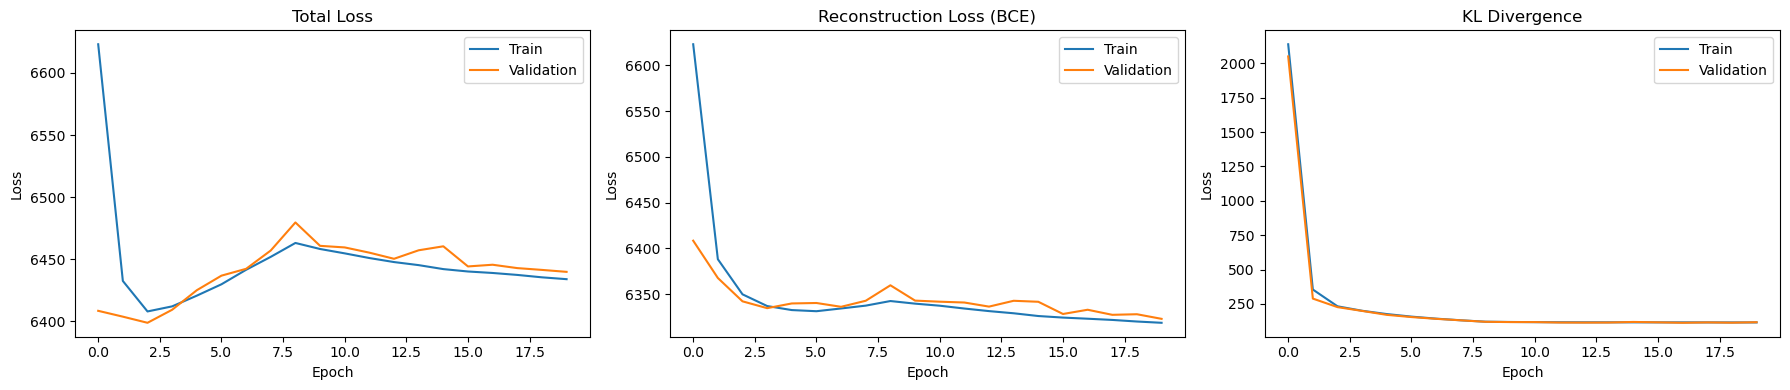

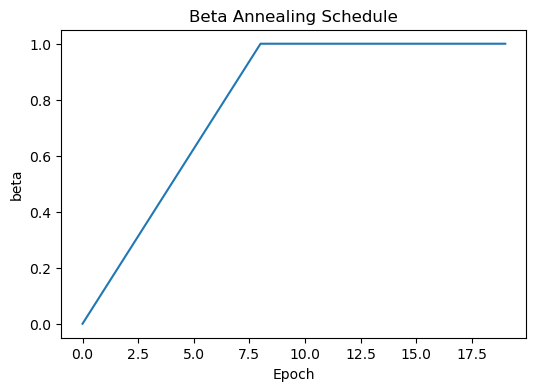

In [41]:
# Plot the convergence curves: total loss, reconstruction loss, KL loss, beta
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(vae_train_losses, label="Train")
axes[0].plot(vae_val_losses, label="Validation")
axes[0].set_title("Total Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(vae_train_recon, label="Train")
axes[1].plot(vae_val_recon, label="Validation")
axes[1].set_title("Reconstruction Loss (BCE)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

axes[2].plot(vae_train_kl, label="Train")
axes[2].plot(vae_val_kl, label="Validation")
axes[2].set_title("KL Divergence")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].legend()

plt.tight_layout()
plt.show()

# Plot the beta schedule separately
plt.figure(figsize=(6, 4))
plt.plot(betas_used)
plt.title("Beta Annealing Schedule")
plt.xlabel("Epoch")
plt.ylabel("beta")
plt.show()

In [43]:
vae.load_state_dict(torch.load("best_vae.pth", map_location=device))
vae.eval()
print("Best VAE model loaded.")

Best VAE model loaded.


<div dir='rtl'>

## تسک :۲ نمایش تصاویر بازتولید شده

</div>

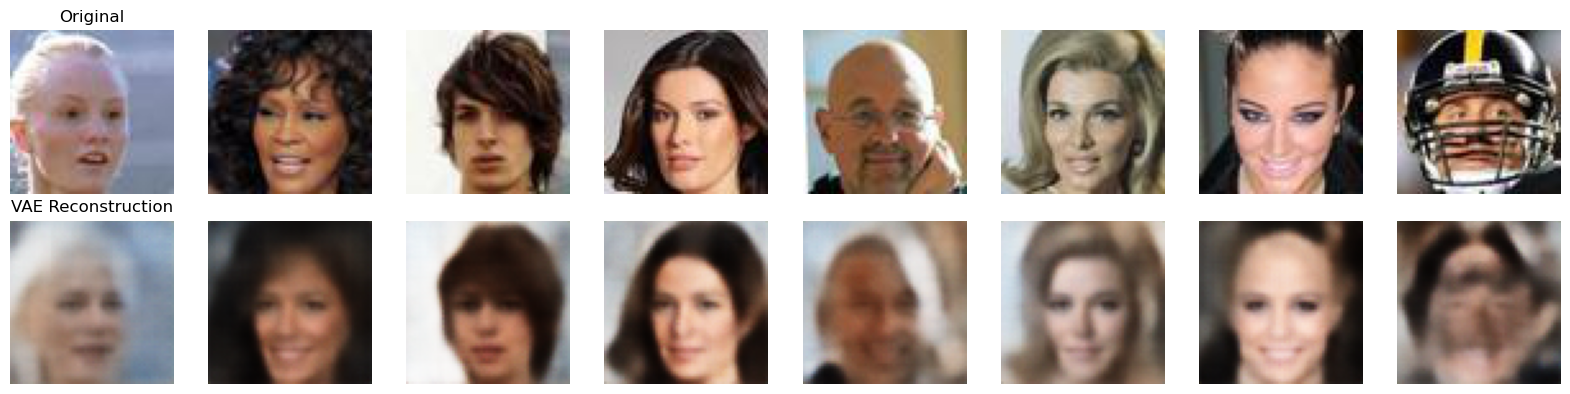

In [48]:
### Reconstructions from the VAE ###
images = next(iter(test_loader))[:8].to(device)

with torch.no_grad():
    recon, mu, logvar = vae(images)

images_cpu = images.cpu()
recon_cpu = recon.cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(images_cpu[i].permute(1, 2, 0))
    axes[0, i].axis("off")

    axes[1, i].imshow(recon_cpu[i].permute(1, 2, 0))
    axes[1, i].axis("off")

axes[0, 0].set_title("Original")
axes[1, 0].set_title("VAE Reconstruction")

plt.tight_layout()
plt.show()


<div dir='rtl'>

## تسک :۳ تولید تصاویر جدید

</div>

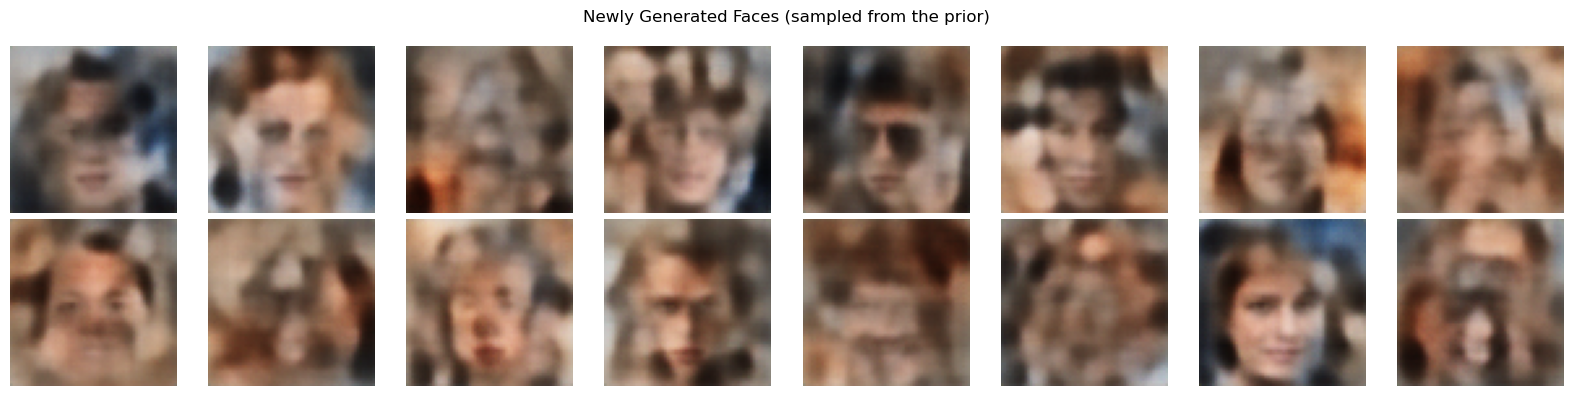

In [52]:
# Generate new faces by sampling from the prior N(0, I)
NUM_SAMPLES = 16

with torch.no_grad():
    z = torch.randn(NUM_SAMPLES, LATENT_DIM_VAE, device=device)
    generated = vae.decode(z).cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated[i].permute(1, 2, 0))
    ax.axis("off")

plt.suptitle("Newly Generated Faces (sampled from the prior)")
plt.tight_layout()
plt.show()

<div dir='rtl'>

## تسک :۴ تبدیل یک عکس به عکس دیگر

</div>

<div dir="ltr">

To morph one face into another we encode both images to get their latent
means `mu_1` and `mu_2`, then walk step by step between them and decode
each intermediate point. As noted in the assignment, a **linear**
interpolation path between two points in a Gaussian latent space tends to
pass through low-probability regions near the origin, which can produce
blurry or unrealistic intermediate faces. Instead we use **spherical linear
interpolation (Slerp)**, which follows the surface of a hypersphere and
stays in higher-probability regions of the latent distribution, producing a
smoother and more realistic transition.

</div>

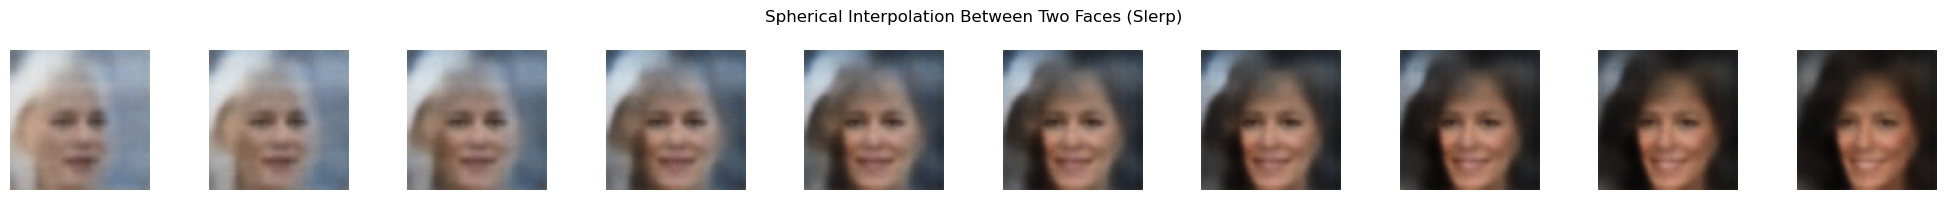

In [53]:
def slerp(z1, z2, t):
    z1_norm = z1 / z1.norm()
    z2_norm = z2 / z2.norm()

    # Angle between the two vectors
    dot = torch.clamp((z1_norm * z2_norm).sum(), -1.0, 1.0)
    omega = torch.acos(dot)

    # Fall back to linear interpolation if the vectors are nearly identical
    if torch.abs(omega) < 1e-4:
        return (1.0 - t) * z1 + t * z2

    sin_omega = torch.sin(omega)
    return (torch.sin((1.0 - t) * omega) / sin_omega) * z1 + \
           (torch.sin(t * omega) / sin_omega) * z2


# Pick two different test images and interpolate between their latents
STEPS = 10

pair = next(iter(test_loader))[:2].to(device)

with torch.no_grad():
    mu_pair, _ = vae.encode(pair)
    z1, z2 = mu_pair[0], mu_pair[1]

    interpolations = []
    for step in range(STEPS):
        t = step / (STEPS - 1)
        z_t = slerp(z1, z2, t)
        img_t = vae.decode(z_t.unsqueeze(0)).squeeze(0).cpu()
        interpolations.append(img_t)

fig, axes = plt.subplots(1, STEPS, figsize=(2 * STEPS, 2))
for i, ax in enumerate(axes):
    ax.imshow(interpolations[i].permute(1, 2, 0))
    ax.axis("off")

plt.suptitle("Spherical Interpolation Between Two Faces (Slerp)")
plt.tight_layout()
plt.show()

<div dir="ltr">

## Task 5: t-SNE Plot of the Latent Space

To understand how the VAE organizes faces in its latent space, we encode a
few hundred test images to their latent means, then use **t-SNE** to
project the high-dimensional latent vectors down to 2 dimensions for
visualization. Clusters or gradients in this plot can reveal how the model
groups faces by visual attributes such as gender presentation, age, or
facial expression, even though it was never given any labels during
training.

</div>

Collected 500 latent vectors of dimension 128


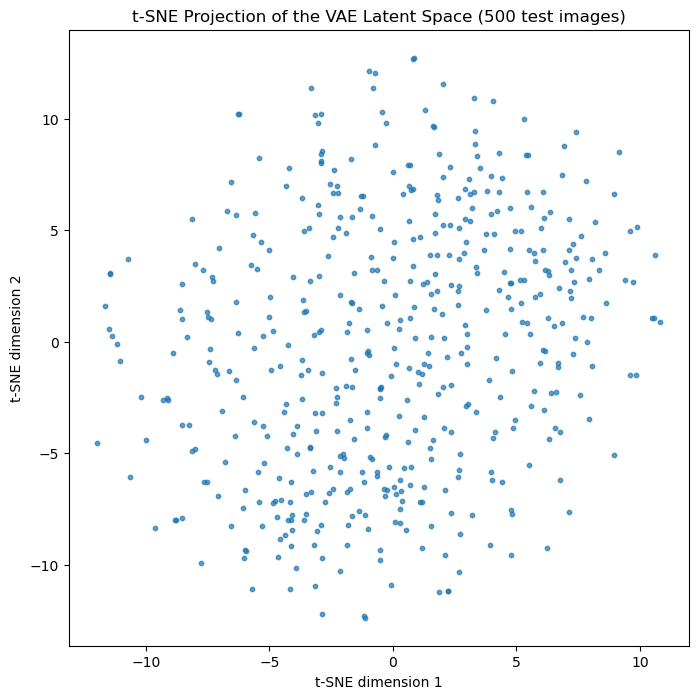

In [47]:
N_TSNE_SAMPLES = 500

# Collect latent means for a batch of images
tsne_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

latents = []

vae.eval()
with torch.no_grad():
    for images in tsne_loader:
        images = images.to(device)
        mu, _ = vae.encode(images)
        latents.append(mu.cpu())

        if sum(l.shape[0] for l in latents) >= N_TSNE_SAMPLES:
            break

latents = torch.cat(latents, dim=0)[:N_TSNE_SAMPLES].numpy()

print(f"Collected {latents.shape[0]} latent vectors of dimension {latents.shape[1]}")

# Reduce to 2D with t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca")
latents_2d = tsne.fit_transform(latents)

plt.figure(figsize=(8, 8))
plt.scatter(latents_2d[:, 0], latents_2d[:, 1], s=10, alpha=0.7)
plt.title("t-SNE Projection of the VAE Latent Space (500 test images)")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.show()

# NOTE: CelebA attribute labels (gender, smiling, etc.) are not loaded in
# this notebook. If attribute annotations are available (e.g. from the
# CelebA "list_attr_celeba.txt" file), color the scatter points by an
# attribute (e.g. `c=attr_values, cmap="coolwarm"`) to visually confirm
# whether the VAE clusters faces by that attribute.
